# Q.6 Principle Component Analysis 
Write codes in Python to perform PCA and understand why we need such unsupervised learning method. Please implement PCA as it has been done in the Nature Primer. See here. You will ALMOST (the data point values may differ a bit, but the patterns will be similar) be reproducing Figure 1 of the paper. The data for all 105 patient samples are organized in three files.

data/class.tsv: has the labels. 1 (ER+ breast cancer), 0 (ER- breast cancer).

data/filtered.tsv.gz: complete dataset. Header is the ID for genes.

data/columns.tsv.gz: ID to gene name mapping.

For example, 4404 is the ID for gene XBP1 (Figure 1a - Y-axis).

Your goal is to:

Extract XBP1 and GATA3 expression levels in all 105 patients, and generate the scatter plot as seen in 1a (coloring should be done by the class). Remember that pattern in your plot should be similar to the paper.

Run PCA on the matrix and project these 2-D points on PC1. Generate Fgure 1c.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
DATA = pd.read_csv("data/PCA/filtered.tsv", sep="\t")
CLASSES = pd.read_csv("data/PCA/class.tsv", sep="\t", header=None)
COLS = pd.read_csv("data/PCA/columns.tsv", sep="\t", comment="#")    

GATA3 = (COLS.loc[COLS['GeneSymbol'] == 'GATA3', 'ID'].values[0])
XBP1 = COLS.loc[COLS['GeneSymbol'] == 'XBP1', 'ID'].values[0]

GATA3 = " " + str(GATA3)
XBP1 = " " + str(XBP1)

X = DATA[GATA3].values
Y = DATA[XBP1].values
Z = CLASSES[0].values
print(f"GATA3 : {GATA3} , XBP1 : {XBP1}")

GATA3 :  4359 , XBP1 :  4404


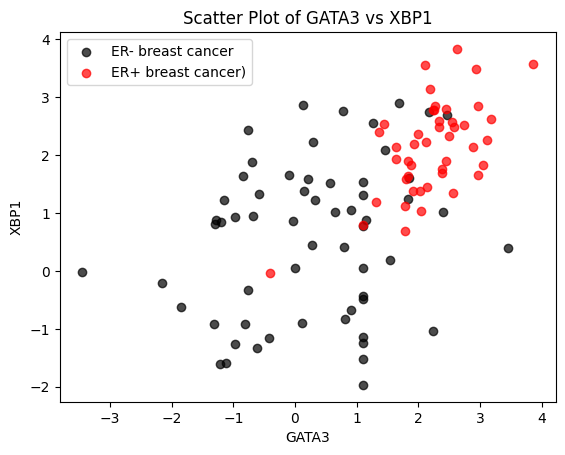

In [10]:
plt.scatter(X[Z == 0], Y[Z == 0], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(X[Z == 1], Y[Z == 1], color='red', alpha=0.7, label='ER+ breast cancer)')

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Scatter Plot of GATA3 vs XBP1")
plt.legend()
plt.show()

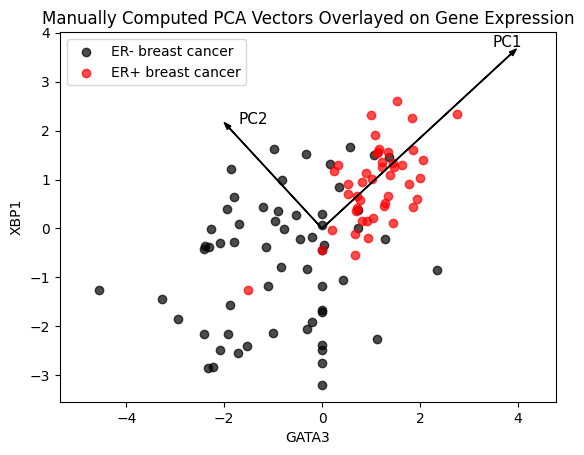

In [ ]:
data = np.vstack((X, Y)).T

# Center the data
mean = np.mean(data, axis=0)
data = (data - mean)

# Compute covariance matrix
COV_MAT = np.cov(data.T)

# Compute eigenvalues and eigenvectors
EIGENVALUES, EIGENVECTORS = np.linalg.eig(COV_MAT)

# Sort eigenvectors by decreasing eigenvalue
sorted_indices = np.argsort(EIGENVALUES)[::-1]
EIGENVALUES = EIGENVALUES[sorted_indices]
EIGENVECTORS = EIGENVECTORS[:, sorted_indices]

plt.scatter(data[Z == 0, 0], data[Z == 0, 1], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(data[Z == 1, 0], data[Z == 1, 1], color='red', alpha=0.7, label='ER+ breast cancer')

# Plot principal component vectors
for i in range(2):
    st = np.array([0, 0])
    en = np.sqrt(EIGENVALUES[i]) * EIGENVECTORS.T[i] * 3
    
    plt.arrow(st[0], st[1], en[0], en[1], color='black', width=0.01, head_width=0.1)
    plt.text(en[0]*0.9, en[1]*1.04, f'PC{i+1}', color='black', fontsize=11)

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Computed PCA Vectors")
plt.legend()
plt.axis('equal')
plt.show()

In [13]:
PC1_PROJ = data @ EIGENVECTORS[:, 0]

DATA = pd.DataFrame({
    "PC1": PC1_PROJ,
    "Group": "All",
    "Color": np.where(Z == 0, "black", "red")
})

ER_MINUS = pd.DataFrame({
    "PC1": PC1_PROJ[Z == 0],
    "Group": "ER-",
    "Color": "black"
})

ER_PLUS = pd.DataFrame({
    "PC1": PC1_PROJ[Z == 1],
    "Group": "ER+",
    "Color": "red"
})

PLOTS = pd.concat([DATA, ER_MINUS, ER_PLUS], ignore_index=True)

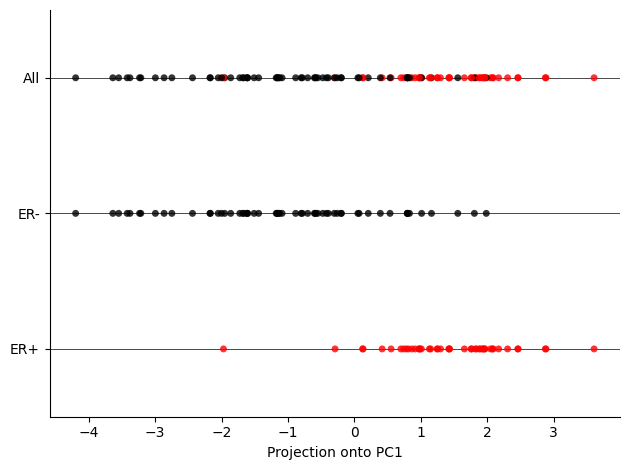

In [14]:
ax = sns.stripplot(data=PLOTS, x="PC1", y="Group", hue="Color", palette={"black": "black", "red": "red"}, dodge=False, jitter=False, alpha=0.8, size=5)
ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0) 

plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

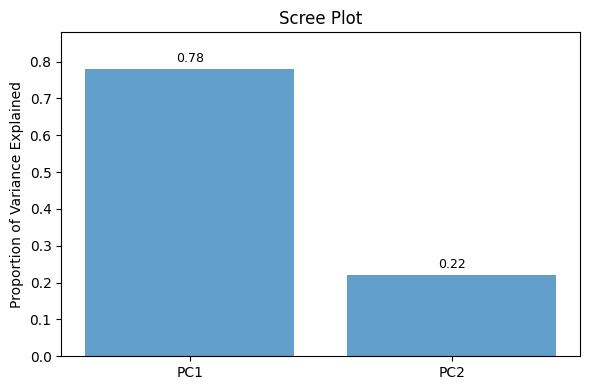

In [15]:
VARIANCE_RATIO = EIGENVALUES / np.sum(EIGENVALUES)

plt.figure(figsize=(6, 4))
PCAS = [f"PC{i+1}" for i in range(len(VARIANCE_RATIO))]
plt.bar(PCAS, VARIANCE_RATIO, alpha=0.7)
for i, v in enumerate(VARIANCE_RATIO):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot')
plt.ylim(0, max(VARIANCE_RATIO) + 0.1)
plt.tight_layout()
plt.show()

PCA (Principal Component Analysis) is a super useful unsupervised learning technique which helps to reduce the dimensionality of complex data while preserving the most important patterns and preserving maximum information, which is perfect for analyzing gene expression data.

1. It helped us clearly see the separation between ER+ and ER- breast cancer samples.

2. By projecting the data onto the first two principal components, we can visualize complex high-dimensional relationships in a 2D space.

3. The XBP1 and GATA3 genes are important markers for distinguishing between breast cancer types, which is evident from their expression patterns.

4. The first principal component (PC1) captures most of the variance in the data and shows a clear separation between the two cancer subtypes.